# Data Generation: Signal and Noise

This notebook generates synthetic data to study the problem of detecting weak predictive
signals in noisy stochastic environments.

We simulate time-series data with a latent signal component and additive noise, allowing
control over signal-to-noise ratio and distributional properties.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(7)

In [2]:
# ----------------------------
# Parameters
# ----------------------------
n = 2000            # number of time steps
phi = 0.85          # AR(1) persistence for the signal
signal_std = 1.0    # volatility of the signal process
noise_std = 2.5     # volatility of noise added to observed feature
beta = 0.08         # strength of predictability
eps_std = 1.0       # idiosyncratic noise in returns

# ----------------------------
# 1) Latent signal s_t (AR(1))
# ----------------------------
s = np.zeros(n)
eta = np.random.normal(0, signal_std, size=n)
for t in range(1, n):
    s[t] = phi * s[t-1] + eta[t]

# ----------------------------
# 2) Observed feature x_t = s_t + measurement noise
# ----------------------------
x = s + np.random.normal(0, noise_std, size=n)

# ----------------------------
# 3) Target y_{t+1}: "future return"
#    y_{t+1} depends weakly on s_t (not x_t directly)
# ----------------------------
y_next = beta * s + np.random.normal(0, eps_std, size=n)

# Align so each row t has (x_t, s_t, y_{t+1})
df = pd.DataFrame({
    "t": np.arange(n),
    "signal_latent_s_t": s,
    "feature_observed_x_t": x,
    "target_return_y_tplus1": np.roll(y_next, -1)
})

# last row has no y_{t+1}; drop it
df = df.iloc[:-1].reset_index(drop=True)

df.head()


,t,signal_latent_s_t,feature_observed_x_t,target_return_y_tplus1
0,0,0.000000,-0.188899,-0.302270
1,1,-0.465937,0.806421,-1.546561
2,2,-0.363227,-2.355569,1.084603
3,3,0.098774,1.401664,0.567179
4,4,-0.704965,-1.469336,-0.888619


In [3]:
df[["signal_latent_s_t", "feature_observed_x_t", "target_return_y_tplus1"]].describe()

,signal_latent_s_t,feature_observed_x_t,target_return_y_tplus1
count,1999.000000,1999.000000,1999.000000
mean,-0.252971,-0.249766,-0.039623
std,1.866176,3.040418,1.009684
min,-5.586286,-10.569038,-3.377558
25%,-1.474221,-2.224596,-0.694628
50%,-0.313147,-0.269261,-0.017173
75%,1.001138,1.758396,0.650977
max,5.933488,10.880120,3.134882


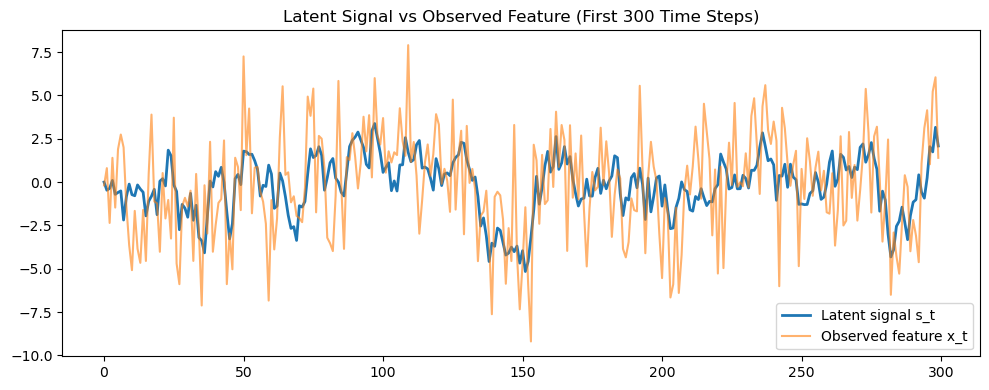

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(df["signal_latent_s_t"][:300], label="Latent signal s_t", linewidth=2)
plt.plot(df["feature_observed_x_t"][:300], label="Observed feature x_t", alpha=0.6)
plt.title("Latent Signal vs Observed Feature (First 300 Time Steps)")
plt.legend()
plt.tight_layout()
plt.show()

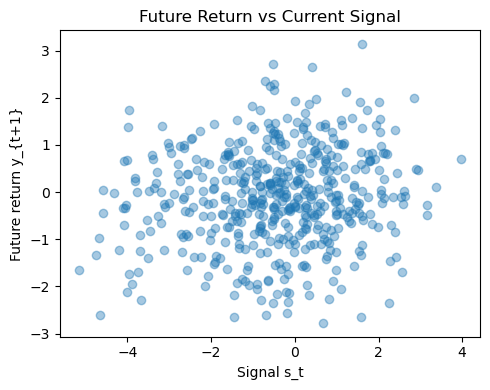

In [5]:
plt.figure(figsize=(5, 4))
plt.scatter(
    df["signal_latent_s_t"][:500],
    df["target_return_y_tplus1"][:500],
    alpha=0.4
)
plt.title("Future Return vs Current Signal")
plt.xlabel("Signal s_t")
plt.ylabel("Future return y_{t+1}")
plt.tight_layout()
plt.show()


In [6]:
df[["signal_latent_s_t", "feature_observed_x_t", "target_return_y_tplus1"]].corr()

,signal_latent_s_t,feature_observed_x_t,target_return_y_tplus1
signal_latent_s_t,1.000000,0.580041,0.104384
feature_observed_x_t,0.580041,1.000000,0.064743
target_return_y_tplus1,0.104384,0.064743,1.000000


## Baseline Predictive Modeling

Now, we evaluate whether the simulated signal exhibits
out-of-sample predictive power. We begin with a simple time-ordered
train/test split to avoid look-ahead bias, followed by a baseline
linear regression model.


In [7]:
# ----------------------------
# Train / Test split (time-ordered)
# ----------------------------
split_ratio = 0.7
split_index = int(len(df) * split_ratio)

train_df = df.iloc[:split_index].copy()
test_df  = df.iloc[split_index:].copy()

# Features and target
X_train = train_df[["feature_observed_x_t"]]
y_train = train_df["target_return_y_tplus1"]

X_test = test_df[["feature_observed_x_t"]]
y_test = test_df["target_return_y_tplus1"]

len(train_df), len(test_df)

(1399, 600)

In [8]:
from sklearn.linear_model import LinearRegression

# Fit baseline linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# In-sample predictions
y_train_pred = model.predict(X_train)

model.coef_, model.intercept_

(array([0.02721517]), np.float64(-0.050334395301693556))

In [9]:
from sklearn.metrics import mean_squared_error, r2_score

# Out-of-sample predictions
y_test_pred = model.predict(X_test)

# In-sample metrics
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

# Out-of-sample metrics
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

mse_train, r2_train, mse_test, r2_test

(1.012131959509231,
 0.006621797024457865,
 1.0226485948584336,
 -0.005736611704966865)

#### Check whether prediction errors behave like random noise, which tells us the model has extracted all usable information.

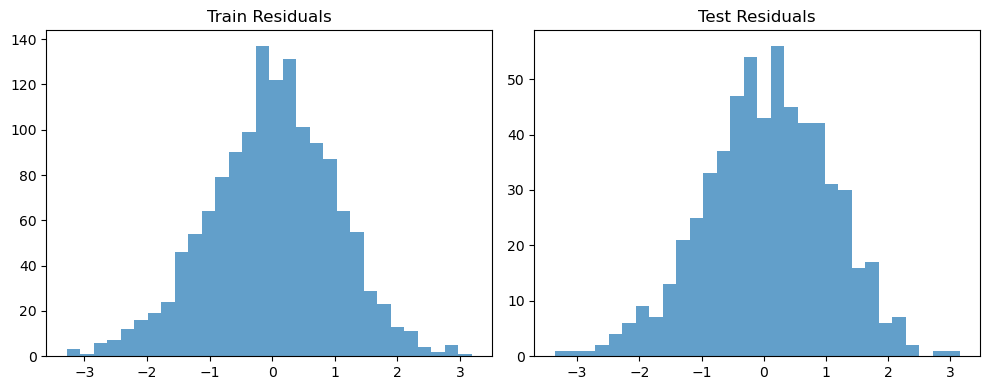

In [10]:
# Residuals
train_residuals = y_train - y_train_pred
test_residuals  = y_test - y_test_pred

# Plot residual distributions
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(train_residuals, bins=30, alpha=0.7)
plt.title("Train Residuals")

plt.subplot(1, 2, 2)
plt.hist(test_residuals, bins=30, alpha=0.7)
plt.title("Test Residuals")

plt.tight_layout()
plt.show()

In [11]:
window = 300  # rolling window size
coefs = []
indices = []

for start in range(0, len(df) - window):
    end = start + window
    window_df = df.iloc[start:end]
    
    X_w = window_df[["feature_observed_x_t"]]
    y_w = window_df["target_return_y_tplus1"]
    
    lr = LinearRegression()
    lr.fit(X_w, y_w)
    
    coefs.append(lr.coef_[0])
    indices.append(end)

rolling_coefs = pd.Series(coefs, index=indices)
rolling_coefs.head()

300    0.026542
301    0.027370
302    0.027510
303    0.028133
304    0.027518
dtype: float64

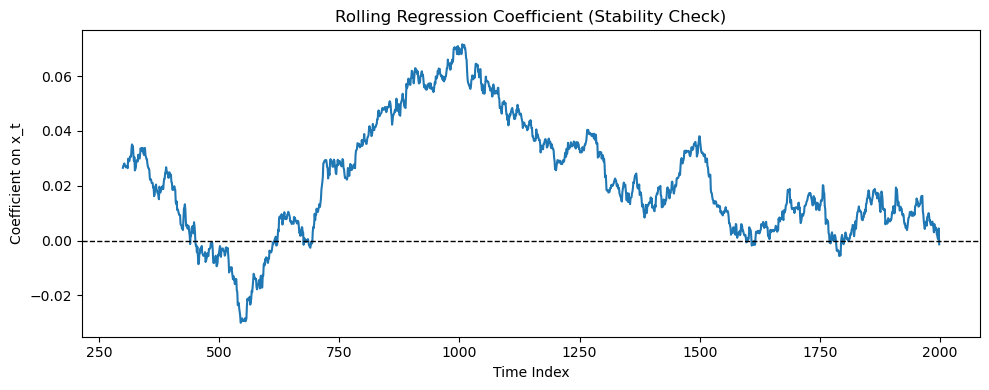

In [12]:
plt.figure(figsize=(10, 4))
rolling_coefs.plot()
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Rolling Regression Coefficient (Stability Check)")
plt.ylabel("Coefficient on x_t")
plt.xlabel("Time Index")
plt.tight_layout()
plt.show()

## Summary & Takeaways

In this project, we constructed a controlled simulation to study the behavior of a weak predictive signal in a noisy environment.

Key findings:
- The latent signal exhibits persistence but is heavily obscured by measurement noise.
- A simple linear model shows mild in-sample predictability that largely disappears out-of-sample.
- Residual diagnostics indicate that remaining variation is consistent with noise.
- Rolling regressions reveal significant instability in the estimated signal strength over time, including frequent sign changes.

Overall, this experiment demonstrates how weak signals can appear statistically meaningful in-sample yet fail to deliver stable, out-of-sample performance, highlighting the importance of validation and stability analysis in quantitative research.


## Interpretation and Diagnostics

The residual distributions for both the training and test sets appear approximately
centered around zero, suggesting no obvious bias in the baseline linear model.
However, the test residuals exhibit greater dispersion, consistent with weaker
out-of-sample performance.

The rolling regression coefficient analysis reveals substantial time variation
in the estimated signal strength. While the coefficient is frequently positive,
its magnitude is unstable and occasionally approaches zero.

This instability indicates that the apparent predictive relationship is fragile
and highly sensitive to the specific sample window, reinforcing the importance
of out-of-sample validation and robustness checks when evaluating weak signals.


## Conclusion

This experiment demonstrates that weak predictive signals can appear statistically
meaningful in-sample yet fail to generalize out-of-sample. Rolling coefficient
instability and residual dispersion highlight the fragility of such signals under noise.
These results emphasize the necessity of time-aware validation and robustness checks
in quantitative research.
